# Results Analysis

Run all three methods under the same setup, compare train/test metrics, and prepare thesis-ready figures.

In [13]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import math
import matplotlib.pyplot as plt

from copy import deepcopy

from src.config import default_data_config, default_hyperparams
from src.data import load_mnist_binary
from src.init import initialize_params
from src.baselines import fit_raw_svm, fit_separate_dict_svm
from src.solver import fit_joint_pg
from src.metrics import (
    summarize_joint_result,
    evaluate_joint_model,
    joint_component_scale_report,
    format_joint_scale_report,
    run_joint_sensitivity_scan,
    summarize_sensitivity_scan,
)

data_cfg = default_data_config()
baseline_hyper = default_hyperparams()
joint_hyper = default_hyperparams()

FINAL_JOINT_CONFIG = {
    'dictionary_size': 128,
    'mu': 0.01,
    'rho': 10.0,
    'eta': 50.0,
    'gamma': 0.01,
    'max_iter': 100,
}

for key, value in FINAL_JOINT_CONFIG.items():
    setattr(joint_hyper, key, value)

print('baseline hyperparameters:', baseline_hyper)
print('final joint hyperparameters:', joint_hyper)

X_train, y_train, X_val, y_val, X_test, y_test = load_mnist_binary(**data_cfg.__dict__)

raw_result = fit_raw_svm(X_train, y_train, X_test, y_test, baseline_hyper)
separate_result = fit_separate_dict_svm(X_train, y_train, X_test, y_test, baseline_hyper)
init_params = initialize_params(X_train, y_train, joint_hyper.dictionary_size, seed=joint_hyper.random_state)
joint_result = fit_joint_pg(X_train, y_train, joint_hyper, init_params)

joint_train_metrics = summarize_joint_result(joint_result, X_train, y_train)
joint_test_metrics = evaluate_joint_model(X_test, y_test, joint_result['params'], joint_hyper)

comparison_rows = [
    {
        'method': 'Raw SVM',
        'train_accuracy': raw_result['metrics']['train_accuracy'],
        'test_accuracy': raw_result['metrics']['test_accuracy'],
        'train_reconstruction_error': None,
        'test_reconstruction_error': None,
        'train_code_sparsity': None,
        'test_code_sparsity': None,
    },
    {
        'method': 'Separate Dict + SVM',
        'train_accuracy': separate_result['metrics']['train_accuracy'],
        'test_accuracy': separate_result['metrics']['test_accuracy'],
        'train_reconstruction_error': separate_result['metrics']['reconstruction_error'],
        'test_reconstruction_error': None,
        'train_code_sparsity': float((abs(separate_result['codes_train']) <= 1e-10).mean()),
        'test_code_sparsity': float((abs(separate_result['codes_test']) <= 1e-10).mean()),
    },
    {
        'method': 'Joint Dict + SVM',
        'train_accuracy': joint_train_metrics['accuracy'],
        'test_accuracy': joint_test_metrics['accuracy'],
        'train_reconstruction_error': joint_train_metrics['reconstruction_error'],
        'test_reconstruction_error': joint_test_metrics['reconstruction_error'],
        'train_code_sparsity': joint_train_metrics['code_sparsity'],
        'test_code_sparsity': joint_test_metrics['code_sparsity'],
    },
]

for row in comparison_rows:
    print(row)

print('joint status:', joint_result['status'])
print('joint iterations:', len(joint_result['history']['objective']))
print('FINAL_JOINT_CONFIG:', FINAL_JOINT_CONFIG)

scale_report = joint_component_scale_report(joint_result)
print(format_joint_scale_report(scale_report))


baseline hyperparameters: HyperParams(dictionary_size=64, mu=0.05, rho=1.0, gamma=0.1, eta=1.0, initial_step=1.0, backtracking_shrink=0.5, backtracking_min_step=1e-08, max_iter=100, tol=1e-05, random_state=7)
final joint hyperparameters: HyperParams(dictionary_size=128, mu=0.01, rho=10.0, gamma=0.01, eta=50.0, initial_step=1.0, backtracking_shrink=0.5, backtracking_min_step=1e-08, max_iter=100, tol=1e-05, random_state=7)
{'method': 'Raw SVM', 'train_accuracy': 1.0, 'test_accuracy': 0.9425, 'train_reconstruction_error': None, 'test_reconstruction_error': None, 'train_code_sparsity': None, 'test_code_sparsity': None}
{'method': 'Separate Dict + SVM', 'train_accuracy': 0.974, 'test_accuracy': 0.945, 'train_reconstruction_error': 106.53963423305966, 'test_reconstruction_error': None, 'train_code_sparsity': 0.000203125, 'test_code_sparsity': 0.0023046875}
{'method': 'Joint Dict + SVM', 'train_accuracy': 1.0, 'test_accuracy': 0.9275, 'train_reconstruction_error': 94.73317524736144, 'test_rec

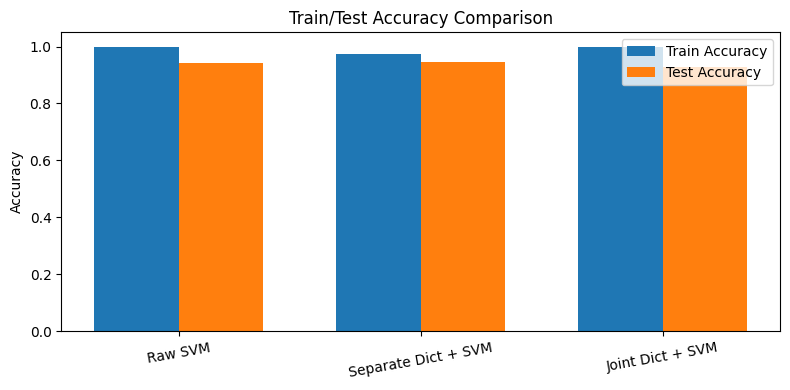

In [14]:
methods = [row['method'] for row in comparison_rows]
train_acc = [row['train_accuracy'] for row in comparison_rows]
test_acc = [row['test_accuracy'] for row in comparison_rows]

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(methods))
width = 0.35
ax.bar([i - width / 2 for i in x], train_acc, width=width, label='Train Accuracy')
ax.bar([i + width / 2 for i in x], test_acc, width=width, label='Test Accuracy')
ax.set_xticks(list(x))
ax.set_xticklabels(methods, rotation=10)
ax.set_ylim(0.0, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('Train/Test Accuracy Comparison')
ax.legend()
plt.tight_layout()
plt.show()

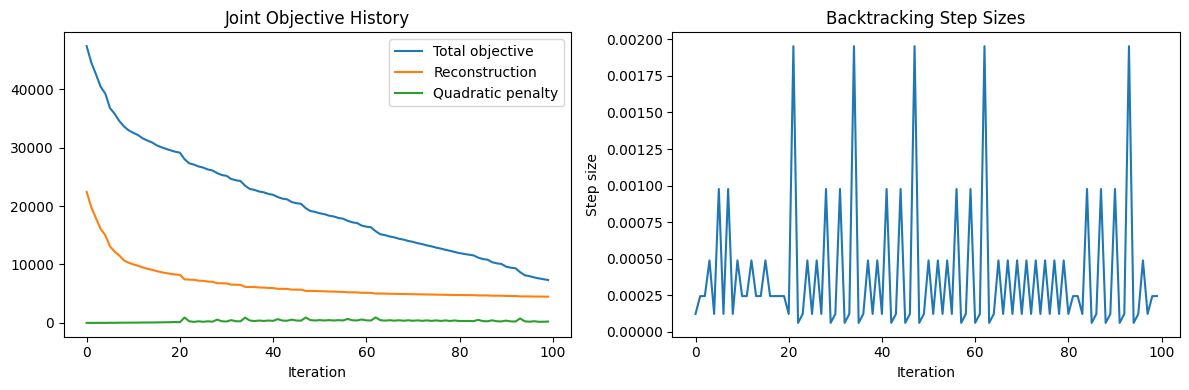

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(joint_result['history']['objective'], label='Total objective')
axes[0].plot(joint_result['history']['reconstruction'], label='Reconstruction')
axes[0].plot(joint_result['history']['quadratic_penalty'], label='Quadratic penalty')
axes[0].set_title('Joint Objective History')
axes[0].set_xlabel('Iteration')
axes[0].legend()

axes[1].plot(joint_result['history']['step_size'])
axes[1].set_title('Backtracking Step Sizes')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Step size')

plt.tight_layout()
plt.show()

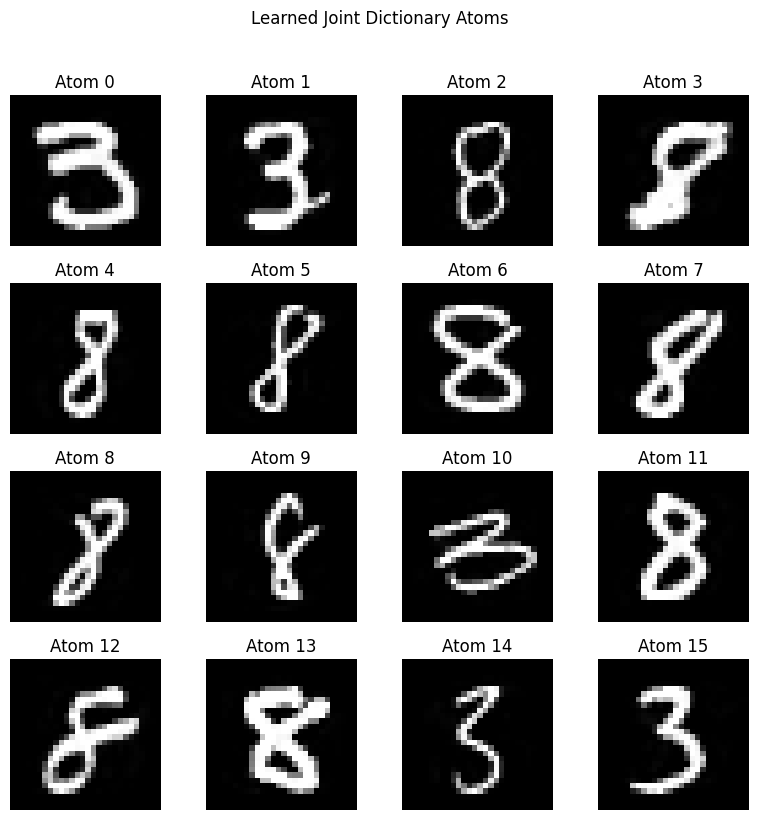

In [16]:
D = joint_result['params']['D']
num_atoms = min(16, D.shape[1])
cols = 4
rows = math.ceil(num_atoms / cols)

fig, axes = plt.subplots(rows, cols, figsize=(8, 2 * rows))
axes = axes.ravel() if hasattr(axes, 'ravel') else [axes]

for idx, ax in enumerate(axes):
    ax.axis('off')
    if idx < num_atoms:
        ax.imshow(D[:, idx].reshape(28, 28), cmap='gray')
        ax.set_title(f'Atom {idx}')

plt.suptitle('Learned Joint Dictionary Atoms', y=1.02)
plt.tight_layout()
plt.show()

{'component': 'reconstruction', 'initial': 22431.76857437429, 'final': 4487.187246223659, 'max': 22431.76857437429, 'final_fraction_of_total': 0.6108867655751007}
{'component': 'quadratic_penalty', 'initial': 0.046566128730773926, 'final': 221.97135223476553, 'max': 939.3108905759289, 'final_fraction_of_total': 0.030219234004809015}
{'component': 'hinge_term', 'initial': 24923.7060546875, 'final': 2592.5820349952114, 'max': 24923.7060546875, 'final_fraction_of_total': 0.35295475025679274}
{'component': 'l1_term', 'initial': 7.667378632861311, 'final': 43.442392415439684, 'max': 43.442392415439684, 'final_fraction_of_total': 0.005914257893705348}
{'component': 'classifier_reg', 'initial': 0.0, 'final': 0.1835773824018812, 'max': 0.1835773824018812, 'final_fraction_of_total': 2.4992269592183376e-05}


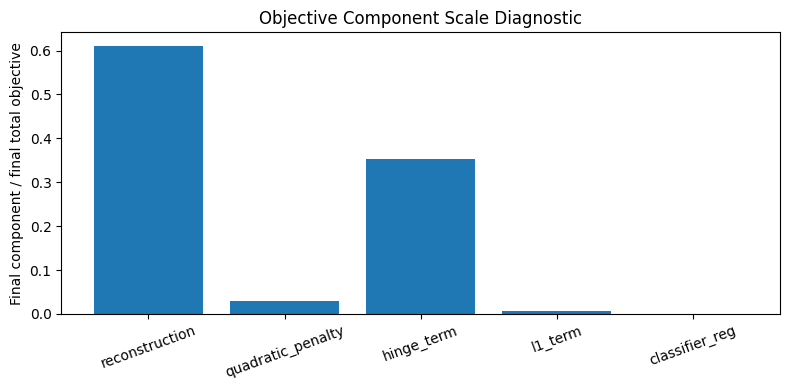

In [17]:
scale_rows = [
    {
        'component': name,
        'initial': stats['initial'],
        'final': stats['final'],
        'max': stats['max'],
        'final_fraction_of_total': stats['final_fraction_of_total'],
    }
    for name, stats in scale_report.items()
]

for row in scale_rows:
    print(row)

components = [row['component'] for row in scale_rows]
fractions = [row['final_fraction_of_total'] for row in scale_rows]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(components, fractions)
ax.set_ylabel('Final component / final total objective')
ax.set_title('Objective Component Scale Diagnostic')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [6]:
diagnostic_scan = run_joint_sensitivity_scan(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    base_hyper=joint_hyper,
    rho_values=[1.0, 10.0, 50.0, 100.0],
    eta_values=[1.0, 10.0, 50.0, 100.0],
    seeds=[joint_hyper.random_state],
)

print(summarize_sensitivity_scan(diagnostic_scan, top_k=8))

for row in diagnostic_scan[:8]:
    print(row)

rank | seed | rho | eta | val_acc | train_acc | final_recon | final_hinge | final_quad | status_ok
1 | 7 | 10 | 50 | 0.965 | 1 | 7662.76 | 3781.93 | 166.25 | 1
2 | 7 | 1 | 100 | 0.96 | 0.983 | 5385.19 | 0 | 90.3218 | 1
3 | 7 | 1 | 1 | 0.96 | 0.941 | 5723.49 | 479.7 | 0.367193 | 1
4 | 7 | 10 | 100 | 0.96 | 1 | 7569.84 | 0 | 75.1096 | 1
5 | 7 | 1 | 10 | 0.955 | 0.947 | 5603.93 | 2819.1 | 39.2864 | 1
6 | 7 | 1 | 50 | 0.955 | 0.978 | 5636.83 | 0 | 118.332 | 1
7 | 7 | 50 | 100 | 0.945 | 0.948 | 12358.3 | 35754.9 | 535.871 | 1
8 | 7 | 10 | 10 | 0.935 | 0.937 | 7457.84 | 4131.4 | 38.2653 | 1
{'seed': 7.0, 'rho': 10.0, 'eta': 50.0, 'train_accuracy': 1.0, 'val_accuracy': 0.965, 'train_reconstruction_error': 123.7962963559681, 'val_reconstruction_error': 55.32205358716787, 'final_reconstruction': 7662.761495727333, 'final_quadratic_penalty': 166.2500163099891, 'final_hinge_term': 3781.9333804416906, 'final_l1_term': 153.3474770761731, 'status_ok': 1.0}
{'seed': 7.0, 'rho': 1.0, 'eta': 100.0, 'tr

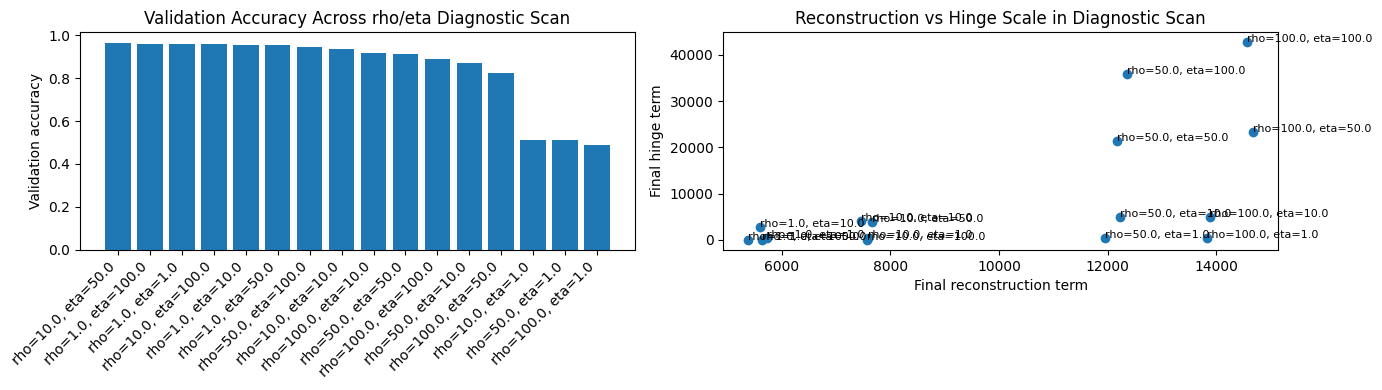

In [7]:
rho_eta_labels = [f"rho={row['rho']}, eta={row['eta']}" for row in diagnostic_scan]
val_acc = [row['val_accuracy'] for row in diagnostic_scan]
recon_final = [row['final_reconstruction'] for row in diagnostic_scan]
hinge_final = [row['final_hinge_term'] for row in diagnostic_scan]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(len(val_acc)), val_acc)
axes[0].set_title('Validation Accuracy Across rho/eta Diagnostic Scan')
axes[0].set_ylabel('Validation accuracy')
axes[0].set_xticks(range(len(val_acc)))
axes[0].set_xticklabels(rho_eta_labels, rotation=45, ha='right')

axes[1].scatter(recon_final, hinge_final)
for idx, label in enumerate(rho_eta_labels):
    axes[1].annotate(label, (recon_final[idx], hinge_final[idx]), fontsize=8)
axes[1].set_title('Reconstruction vs Hinge Scale in Diagnostic Scan')
axes[1].set_xlabel('Final reconstruction term')
axes[1].set_ylabel('Final hinge term')

plt.tight_layout()
plt.show()

## Interpretation Notes

- Compare `test_accuracy` across all three methods, not baseline test accuracy against joint train accuracy.
- The joint method evaluates the test split by fixing the learned dictionary and classifier, then inferring sparse codes for the test images.
- Before changing the formula, inspect whether the reconstruction term dominates the classification-related terms by a large margin.
- If the reconstruction term is consistently much larger than the quadratic penalty and hinge term, objective normalization becomes a justified next step rather than an arbitrary rewrite.
- The `rho/eta` diagnostic scan is not the final tuning stage. It is a sensitivity check used to decide whether the current objective scaling is already workable.
- If the joint method is still weaker after diagnostics, the next suspects are hyperparameters (`mu`, `rho`, `eta`, `gamma`), dictionary size, and optimization budget (`max_iter`).